## NSGA-II

In [1]:
from mofgbmlpy.utility.parallel_cross_validation import run_cross_validation

In [2]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"Basic{data_name}Basic"
    dataset_root = root_folder + "/dataset"
    
    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "nsga2",
    ]
    
    run_cross_validation(args, dataset_root)

Execution time: 53.10811448097229
Execution time: 186.83091187477112
Execution time: 82.7646336555481


=========== DATASET iris ===========



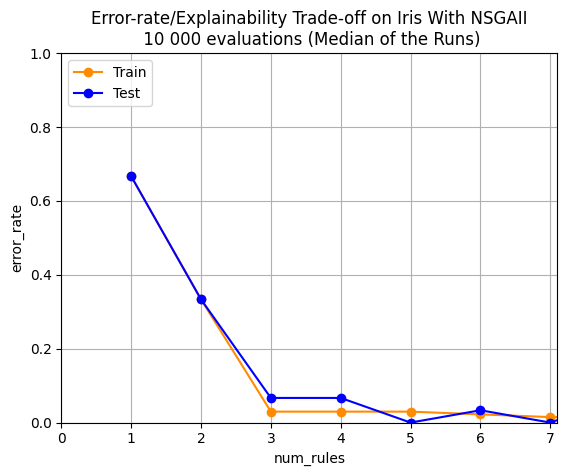

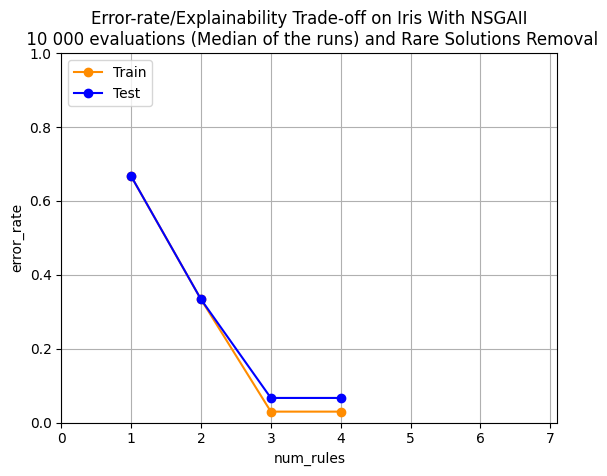

Q1:  14.378410696983337
Median :  15.218255639076233
Q3:  15.732383728027344
Average :  14.67102636496226
Std:  1.5855523140735575
=========== DATASET pima ===========



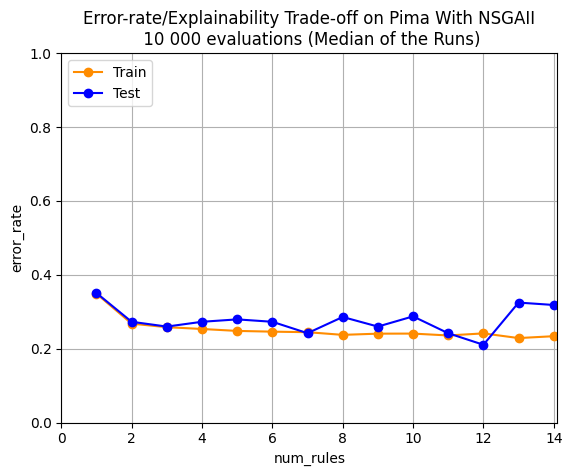

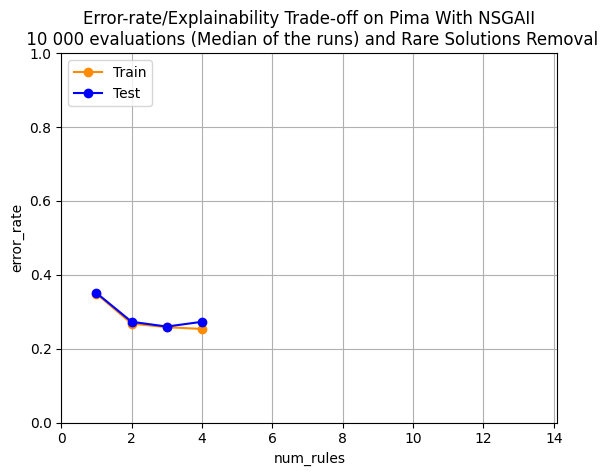

Q1:  48.62086379528046
Median :  53.05802047252655
Q3:  56.301748394966125
Average :  52.34551587104797
Std:  6.048929162826534
=========== DATASET bupa ===========



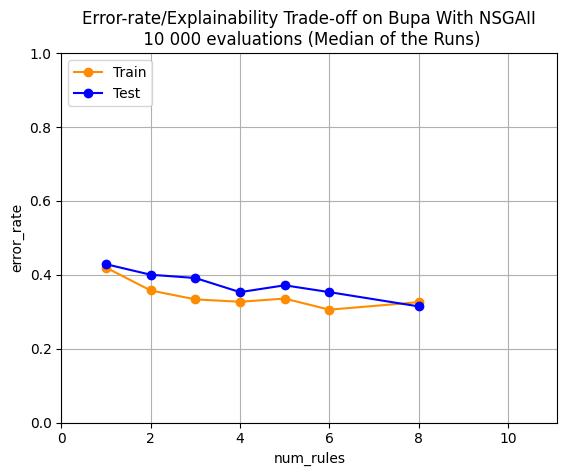

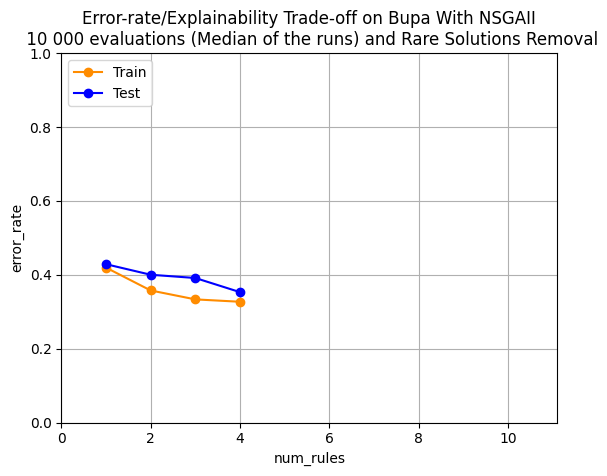

Q1:  23.2419536113739
Median :  24.093719840049744
Q3:  24.752639174461365
Average :  23.157142504056296
Std:  3.0185297367920327


In [3]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,7.1),
    "pima": (0,14.1),
    "bupa": (0,11.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"Basic{data_name}Basic"
    dataset_root = root_folder + "/dataset"
    
    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]
    
    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)
        
    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()
    
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))


## MOEA/D

In [4]:
for data_name in ["iris", "pima", "bupa"]:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"MOEAD{data_name}Basic"
    dataset_root = root_folder + "/dataset"

    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "moead",
    ]

    run_cross_validation(args, dataset_root)

Execution time: 62.992921113967896
Execution time: 171.07353448867798
Execution time: 91.02402329444885


=========== DATASET iris ===========



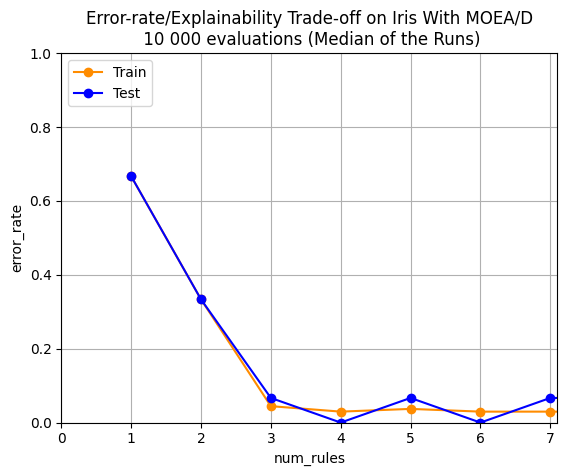

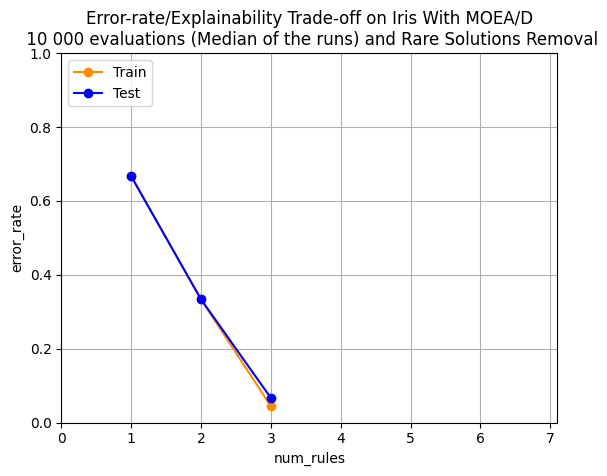

Q1:  18.427879512310028
Median :  18.741034269332886
Q3:  19.697277069091797
Average :  18.241954565048218
Std:  2.1574409873867473
=========== DATASET pima ===========



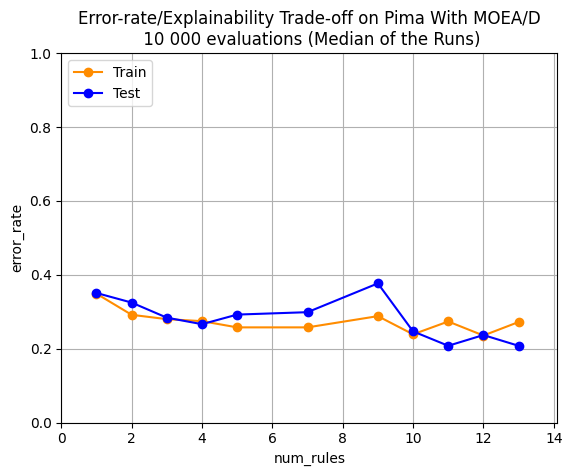

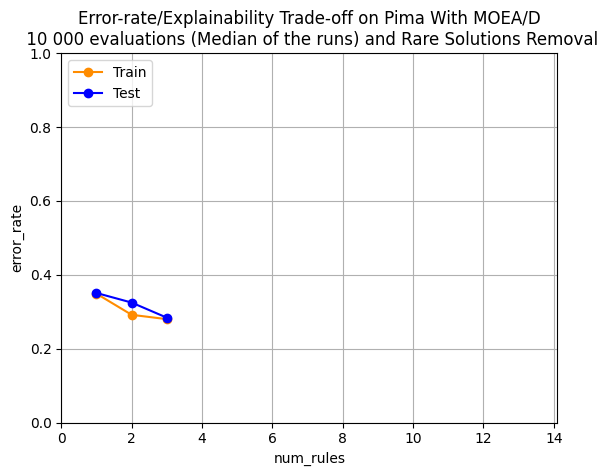

Q1:  50.034106969833374
Median :  52.35133361816406
Q3:  53.44559645652771
Average :  50.046999549865724
Std:  6.207344198011369
=========== DATASET bupa ===========



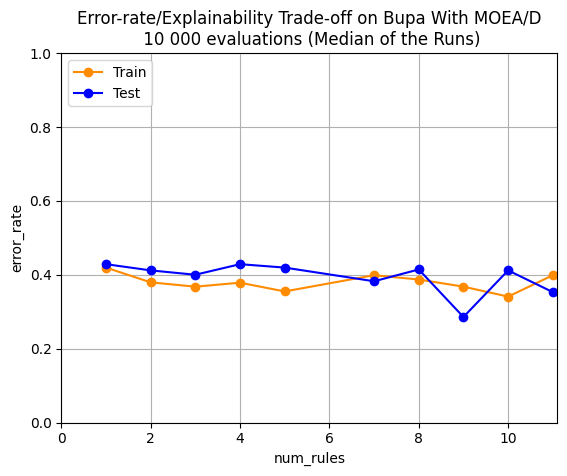

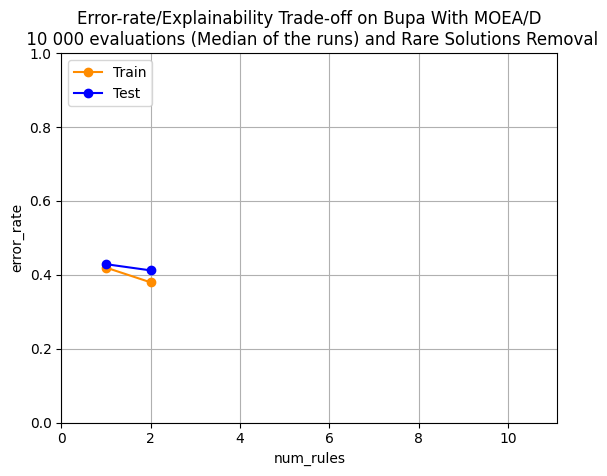

Q1:  26.90219223499298
Median :  27.606019139289856
Q3:  29.583172917366028
Average :  26.978902689615886
Std:  4.1050923296056885


In [5]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,7.1),
    "pima": (0,14.1),
    "bupa": (0,11.1),
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in ["iris", "pima", "bupa"]:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"MOEAD{data_name}Basic"
    dataset_root = root_folder + "/dataset"

    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]

    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)

    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()

    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))